In [3]:
%pip install transformers

from transformers import GPT2LMHeadModel

Note: you may need to restart the kernel to use updated packages.


In [4]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2-xl") # 124M
sd_hf = model_hf.state_dict()

for k, v in sd_hf.items():
    print(k, v.shape)

Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

transformer.wte.weight torch.Size([50257, 1600])
transformer.wpe.weight torch.Size([1024, 1600])
transformer.h.0.ln_1.weight torch.Size([1600])
transformer.h.0.ln_1.bias torch.Size([1600])
transformer.h.0.attn.c_attn.weight torch.Size([1600, 4800])
transformer.h.0.attn.c_attn.bias torch.Size([4800])
transformer.h.0.attn.c_proj.weight torch.Size([1600, 1600])
transformer.h.0.attn.c_proj.bias torch.Size([1600])
transformer.h.0.ln_2.weight torch.Size([1600])
transformer.h.0.ln_2.bias torch.Size([1600])
transformer.h.0.mlp.c_fc.weight torch.Size([1600, 6400])
transformer.h.0.mlp.c_fc.bias torch.Size([6400])
transformer.h.0.mlp.c_proj.weight torch.Size([6400, 1600])
transformer.h.0.mlp.c_proj.bias torch.Size([1600])
transformer.h.1.ln_1.weight torch.Size([1600])
transformer.h.1.ln_1.bias torch.Size([1600])
transformer.h.1.attn.c_attn.weight torch.Size([1600, 4800])
transformer.h.1.attn.c_attn.bias torch.Size([4800])
transformer.h.1.attn.c_proj.weight torch.Size([1600, 1600])
transformer.h.1

In [5]:
sd_hf["transformer.wpe.weight"].view(-1)[:20]

tensor([ 0.0673, -0.0098, -0.0134, -0.0019,  0.0026,  0.0075,  0.0042,  0.0056,
         0.0348,  0.0055, -0.0535, -0.0047, -0.0095, -0.0169,  0.0027,  0.0066,
        -0.0026,  0.0068,  0.0129, -0.0400])

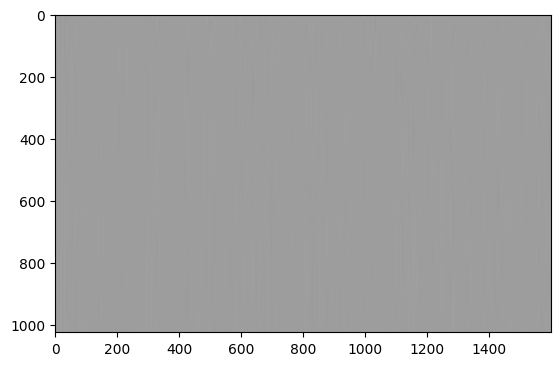

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(sd_hf["transformer.wpe.weight"], cmap="gray")

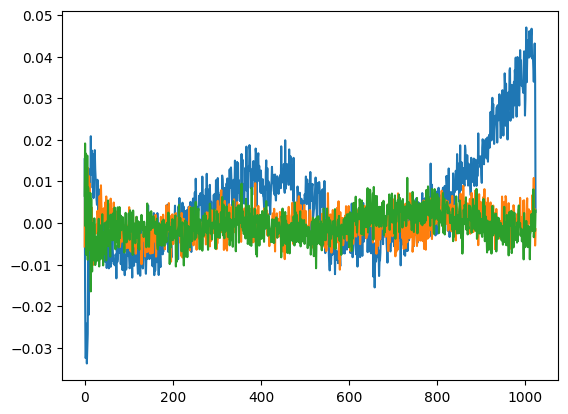

In [7]:
plt.plot(sd_hf["transformer.wpe.weight"][:, 150])
plt.plot(sd_hf["transformer.wpe.weight"][:, 200])
plt.plot(sd_hf["transformer.wpe.weight"][:, 250])

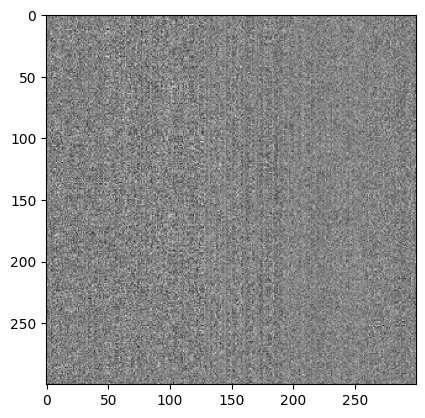

In [8]:
plt.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"][:300, :300], cmap="gray")

In [9]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation', model='gpt2')
set_seed(42)
generator("Hello, I'm a language model,", max_length=30, num_return_sequences=5)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 1.94 GiB of which 37.19 MiB is free. Including non-PyTorch memory, this process has 876.00 MiB memory in use. Of the allocated memory 761.40 MiB is allocated by PyTorch, and 56.60 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [14]:
import torch
from torch.nn import functional as F
from transformers import GPT2LMHeadModel

model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()
model.to('cpu') # was cuda
# set the seed to 42
torch.manual_seed(42)
#torch.cuda.manual_seed(42)
tokens = [15496, 11, 314, 1101, 257, 3303, 2746, 11] # Hello, I'm a language model,
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(5, 1) # (5, 8)
x = tokens.to('cpu') # was cuda

# generate! right now x is (B, T) where B = 5 and T = 0

while x.size(1) < 30:
    # forward the model to get the logits
    with torch.no_grad():
        logits = model(x)[0] # (B, T, vocab_size)
        # take the logits at the last position
        logits = logits[:, -1, :] # (B, vocab_size)
        # get the probs
        probs = F.softmax(logits, dim=-1)
        # do top-k samling of 50 (huggingface pipeline default)
        # topk_probs here becomes (5, 50), topk_indicies is (5, 50)
        topk_probs, topk_indices = torch.topk(probs, 50, dim=-1)
        # select a token from the top-k probs
        ix = torch.multinomial(topk_probs, 1) #  (B, 1)
        # gather the corresponding indices
        xcol = torch.gather(topk_indices, -1, ix) # (B, 1)
        # append to the sequences
        x = torch.cat((x, xcol), dim=1)

import tiktoken
enc = tiktoken.get_encoding('gpt2')
for i in range(5):
    tokens = x[i, :30].tolist()
    decode = enc.decode(tokens)
    print(">", decode)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

> Hello, I'm a language model, not a programming platform! I just make decisions based on other projects. I try to do that."


> Hello, I'm a language model, a kind of a "first class citizen" of the world and a person that comes from a much more egalitarian
> Hello, I'm a language model, and I'm starting to talk about the notion of the syntax, and I'm also working on an extension that
> Hello, I'm a language model, because I'm writing real-time. I'm writing all languages. And I'm working with languages for me
> Hello, I'm a language model, I don't know where to begin but I know there is a big deal going on with our society. What


In [ ]:
#!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open("input.txt", "r") as f:
    text = f.read()
data = text[:1000] # first 1000 chars
print(data[:100])

--2026-04-24 20:43:49--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8002::154, 2606:50c0:8000::154, 2606:50c0:8001::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8002::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt.1’

input.txt.1         100%[===================>]   1.06M  4.98MB/s    in 0.2s    

2026-04-24 20:43:49 (4.98 MB/s) - ‘input.txt.1’ saved [1115394/1115394]

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


In [16]:
import tiktoken
enc = tiktoken.get_encoding('gpt2')
tokens = enc.encode(data)
print(tokens[:24])

[5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13]


In [19]:
import torch
buf = torch.tensor(tokens[:24 + 1])
x = buf[:-1].view(4, 6)
y = buf[1:].view(4, 6)
print(x)
print(y)

tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])
tensor([[22307,    25,   198,  8421,   356,  5120],
        [  597,  2252,    11,  3285,   502,  2740],
        [   13,   198,   198,  3237,    25,   198],
        [ 5248,   461,    11,  2740,    13,   198]])


In [20]:
print(sd_hf["lm_head.weight"].shape)
print(sd_hf["transformer.wte.weight"].shape)

torch.Size([50257, 1600])
torch.Size([50257, 1600])


In [22]:
(sd_hf["lm_head.weight"] == sd_hf["transformer.wte.weight"]).all()

tensor(True)

In [23]:
print(sd_hf["lm_head.weight"].data_ptr())
print(sd_hf["transformer.wte.weight"].data_ptr())

124169892267724
124169892267724


In [26]:
# stddev grows inside the residual stream
x = torch.zeros(768)
n = 100 # e.g 100 layers
for i in range(n):
    x += n**-0.5*torch.randn(768)
    
print(x.std())

tensor(0.9960)
